In [2]:
from statsmodels.datasets import get_rdataset
import pandas as pd

data = get_rdataset("AirPassengers").data
y = data["value"].values
     

Exploracion de datos:

In [3]:
data.head()

,time,value
0,1949.000000,112
1,1949.083333,118
2,1949.166667,132
3,1949.250000,129
4,1949.333333,121


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    144 non-null    float64
 1   value   144 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 2.4 KB


In [5]:
import pandas as pd

df = pd.DataFrame({
    "fecha": pd.date_range(
        start="1949-01-01",
        periods=len(y),
        freq="MS"
    ),
    "y": y
})

df = df.set_index("fecha")

In [7]:
import numpy as np

df["mes"] = df.index.month
df["trimestre"] = df.index.quarter
df["año"] = df.index.year
df["dia_año"] = df.index.dayofyear

df["mes_sin"] = np.sin(2 * np.pi * df["mes"] / 12)
df["mes_cos"] = np.cos(2 * np.pi * df["mes"] / 12)

df["dia_año_sin"] = np.sin(
    2 * np.pi * df["dia_año"] / 365.25
)
df["dia_año_cos"] = np.cos(
    2 * np.pi * df["dia_año"] / 365.25
)

In [8]:
for ventana in [3, 12]:
    serie_pasada = df["y"].shift(1)

    df[f"rolling_mean_{ventana}"] = (
        serie_pasada.rolling(ventana).mean()
    )
    df[f"rolling_std_{ventana}"] = (
        serie_pasada.rolling(ventana).std()
    )
    df[f"rolling_max_{ventana}"] = (
        serie_pasada.rolling(ventana).max()
    )
    df[f"rolling_min_{ventana}"] = (
        serie_pasada.rolling(ventana).min()
    )

In [9]:
df["expanding_mean"] = (
    df["y"].shift(1).expanding().mean()
)

df["expanding_std"] = (
    df["y"].shift(1).expanding().std()
)

In [12]:
features_fecha = [
    "mes",
    "trimestre",
    "año",
    "dia_año",
    "mes_sin",
    "mes_cos",
    "dia_año_sin",
    "dia_año_cos"
]

In [13]:
features_all = [
    columna
    for columna in df.columns
    if columna != "y"
]

In [14]:
df_modelo = df.dropna().copy()

In [15]:
train_temporal = df_modelo.iloc[:-24]
test_temporal = df_modelo.iloc[-24:]

In [16]:
from sklearn.model_selection import train_test_split

train_shuffle, test_shuffle = train_test_split(
    df_modelo,
    test_size=24,
    shuffle=True,
    random_state=42
)

In [17]:
from sklearn.ensemble import GradientBoostingRegressor

def entrenar_modelo(train, test, features):
    X_train = train[features]
    y_train = train["y"]

    X_test = test[features]
    y_test = test["y"]

    modelo = GradientBoostingRegressor(
        random_state=42
    )

    modelo.fit(X_train, y_train)
    predicciones = modelo.predict(X_test)

    return modelo, y_test, predicciones

In [18]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

def calcular_metricas(y_true, y_pred, y_train):
    mae = mean_absolute_error(y_true, y_pred)

    rmse = mean_squared_error(
        y_true,
        y_pred
    ) ** 0.5

    mape = (
        mean_absolute_percentage_error(
            y_true,
            y_pred
        ) * 100
    )

    error_naive = np.mean(
        np.abs(
            y_train.values[12:] -
            y_train.values[:-12]
        )
    )

    mase = mae / error_naive

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "MASE": mase
    }

In [22]:
modelos = {}

modelos["fecha_temporal"], _, _ = entrenar_modelo(
    train_temporal, test_temporal, features_fecha
)

modelos["all_temporal"], _, _ = entrenar_modelo(
    train_temporal, test_temporal, features_all
)

modelos["fecha_shuffle"], _, _ = entrenar_modelo(
    train_shuffle, test_shuffle, features_fecha
)

modelos["all_shuffle"], _, _ = entrenar_modelo(
    train_shuffle, test_shuffle, features_all
)

In [23]:
modelo_all_temporal = modelos["all_temporal"]

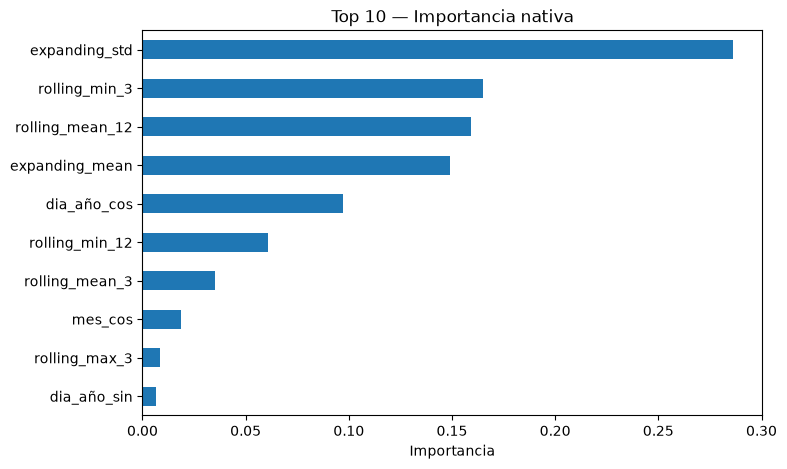

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

importancia_nativa = pd.Series(
    modelo_all_temporal.feature_importances_,
    index=features_all
).sort_values(ascending=False)

importancia_nativa.head(10).sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Top 10 — Importancia nativa")
plt.xlabel("Importancia")
plt.show()

In [25]:
from sklearn.inspection import permutation_importance

resultado_perm = permutation_importance(
    modelo_all_temporal,
    test_temporal[features_all],
    test_temporal["y"],
    scoring="neg_mean_absolute_error",
    n_repeats=30,
    random_state=42
)

importancia_perm = pd.Series(
    resultado_perm.importances_mean,
    index=features_all
).sort_values(ascending=False)